<a href="https://colab.research.google.com/github/devpatel0005/TechMicra-AIML-Summer-Internship/blob/main/Stock_Sentiment_Analysis_and_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import pandas as pd

### Data Analysis and Basic EDA

In [6]:
df=pd.read_csv('https://raw.githubusercontent.com/devpatel0005/TechMicra-AIML-Summer-Internship/refs/heads/main/Datasets/Sentiment_Stock_data.csv')
df.sample(5)

,Unnamed: 0,Sentiment,Sentence
21710,22559,1,Battle to lead TUC begins
6354,6657,1,Press release 9 October 2009 Ruukki has signed...
52147,54292,0,Independent NHS to be ruled out
92695,95233,0,Vladimir Putin claims Russia is moral compass ...
7744,8258,0,Linde acts responsibly towards its shareholder...


In [7]:
df.isnull().sum()

,0
Unnamed: 0,0
Sentiment,0
Sentence,1


In [8]:
df = df.dropna()

In [9]:
df = df.drop_duplicates()

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 108750 entries, 0 to 108750
Data columns (total 4 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   Sentiment        108750 non-null  int64 
 1   Sentence         108750 non-null  object
 2   Sentence_Length  108750 non-null  int64 
 3   Word_Count       108750 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 4.1+ MB


In [10]:
# Display the shape of the DataFrame
print(f"Shape of the DataFrame: {df.shape}")

Shape of the DataFrame: (108750, 3)


In [11]:
# Check the distribution of 'Sentiment'
print("Sentiment Distribution:")
display(df['Sentiment'].value_counts())

Sentiment Distribution:


,count
Sentiment,
1,55724
0,53026


The `Unnamed: 0` column seems to be an old index. Let's drop it as it is not useful for sentiment analysis.

In [12]:
# Drop the 'Unnamed: 0' column
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
    print("Dropped 'Unnamed: 0' column.")
else:
    print("'Unnamed: 0' column not found.")

# Display DataFrame information after dropping the column
df.info()

Dropped 'Unnamed: 0' column.
<class 'pandas.core.frame.DataFrame'>
Index: 108750 entries, 0 to 108750
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Sentiment  108750 non-null  int64 
 1   Sentence   108750 non-null  object
dtypes: int64(1), object(1)
memory usage: 2.5+ MB


Let's visualize the sentiment distribution.

/tmp/ipykernel_946/2832920033.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sentiment', data=df, palette='viridis')


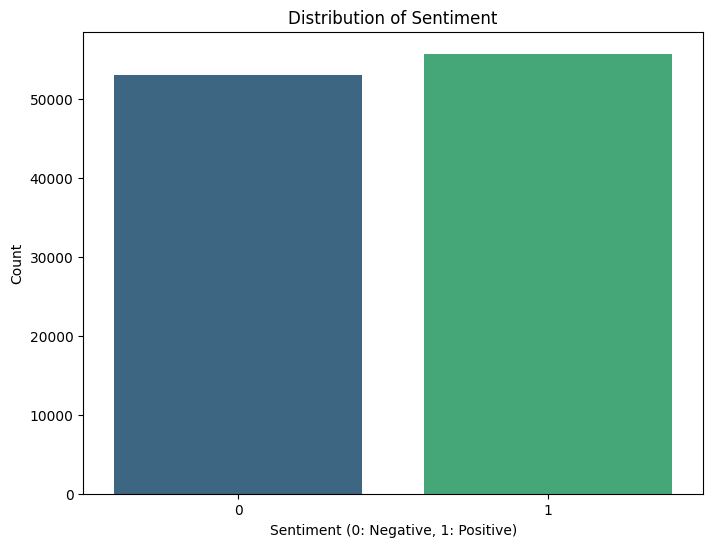

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='Sentiment', data=df, palette='viridis')
plt.title('Distribution of Sentiment')
plt.xlabel('Sentiment (0: Negative, 1: Positive)')
plt.ylabel('Count')
plt.show()

### Text Data Analysis (Sentence Length and Word Count)

In [15]:
# Calculate sentence length
df['Sentence_Length'] = df['Sentence'].apply(len)

# Calculate word count
df['Word_Count'] = df['Sentence'].apply(lambda x: len(str(x).split()))

# Display descriptive statistics for these new columns
print("Descriptive statistics for Sentence Length:")
display(df['Sentence_Length'].describe())

print("\nDescriptive statistics for Word Count:")
display(df['Word_Count'].describe())

Descriptive statistics for Sentence Length:


,Sentence_Length
count,108750.000000
mean,76.941067
std,62.399292
min,1.000000
25%,36.000000
50%,53.000000
75%,94.000000
max,315.000000



Descriptive statistics for Word Count:


,Word_Count
count,108750.000000
mean,12.607807
std,10.337058
min,1.000000
25%,6.000000
50%,9.000000
75%,15.000000
max,81.000000


Let's visualize the distribution of sentence lengths and word counts.

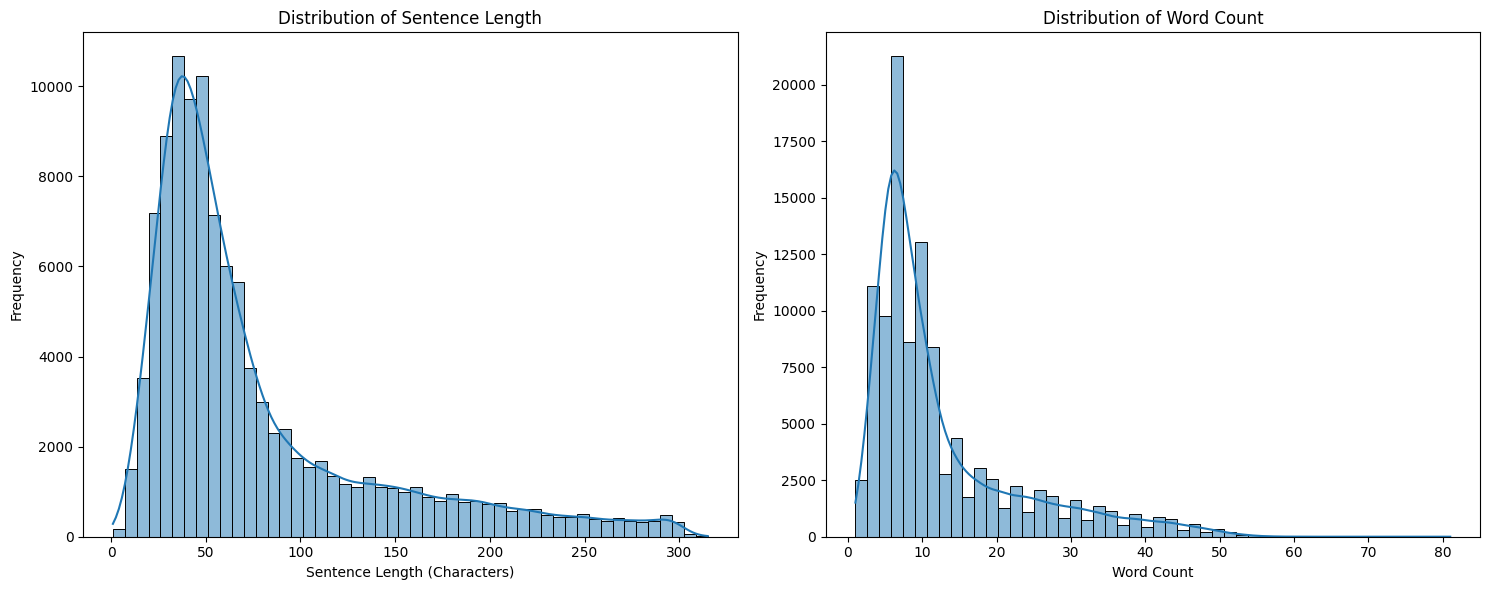

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(df['Sentence_Length'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Sentence Length')
axes[0].set_xlabel('Sentence Length (Characters)')
axes[0].set_ylabel('Frequency')

sns.histplot(df['Word_Count'], bins=50, kde=True, ax=axes[1])
axes[1].set_title('Distribution of Word Count')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### EDA Summary

So far, we have:
- Loaded the dataset and inspected its initial rows.
- Handled missing values by dropping the row with a null 'Sentence'.
- Removed duplicate entries.
- Identified and removed an irrelevant 'Unnamed: 0' column.
- Examined the overall shape of the dataset.
- Analyzed and visualized the distribution of sentiment (positive vs. negative).
- Explored the characteristics of the text data by calculating and visualizing the distribution of sentence lengths and word counts.

This initial EDA provides a good foundation for understanding the dataset and prepares us for subsequent text preprocessing and model building steps.

### Feature Engineering and Preprocessing

To prepare the text data for machine learning models, we need to convert it into a numerical format. TF-IDF (Term Frequency-Inverse Document Frequency) is a common technique that reflects how important a word is to a document in a collection or corpus.

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limiting to top 5000 features for manageable size

# Fit and transform the 'Sentence' column
X_tfidf = tfidf_vectorizer.fit_transform(df['Sentence'])

print(f"Shape of TF-IDF features: {X_tfidf.shape}")

Shape of TF-IDF features: (108750, 5000)


Now, let's combine the TF-IDF features with the numerical features ('Sentence_Length', 'Word_Count') we engineered earlier. This creates a comprehensive feature set for our model.

In [19]:
from scipy.sparse import hstack

# Extract numerical features
numerical_features = df[['Sentence_Length', 'Word_Count']].values

# Combine TF-IDF features with numerical features
X = hstack([X_tfidf, numerical_features])

# Define the target variable
y = df['Sentiment']

print(f"Shape of combined features (X): {X.shape}")
print(f"Shape of target variable (y): {y.shape}")

Shape of combined features (X): (108750, 5002)
Shape of target variable (y): (108750,)


Finally, we will split the data into training and testing sets. This is crucial for evaluating the model's performance on unseen data. A common split is 80% for training and 20% for testing.

In [20]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (87000, 5002)
Shape of X_test: (21750, 5002)
Shape of y_train: (87000,)
Shape of y_test: (21750,)
